In [10]:
import pandas as pd

sentiment = pd.read_csv("fear_greed_index.csv")
trades = pd.read_csv("historical_data.csv")
#load both files

In [11]:
sentiment.info()
trades.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2644 entries, 0 to 2643
Data columns (total 4 columns):
 #   Column          Non-Null Count  Dtype 
---  ------          --------------  ----- 
 0   timestamp       2644 non-null   int64 
 1   value           2644 non-null   int64 
 2   classification  2644 non-null   object
 3   date            2644 non-null   object
dtypes: int64(2), object(2)
memory usage: 82.8+ KB
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 211224 entries, 0 to 211223
Data columns (total 16 columns):
 #   Column            Non-Null Count   Dtype  
---  ------            --------------   -----  
 0   Account           211224 non-null  object 
 1   Coin              211224 non-null  object 
 2   Execution Price   211224 non-null  float64
 3   Size Tokens       211224 non-null  float64
 4   Size USD          211224 non-null  float64
 5   Side              211224 non-null  object 
 6   Timestamp IST     211224 non-null  object 
 7   Start Position    211224 non-nu

In [12]:
trades.head()


,Account,Coin,Execution Price,Size Tokens,Size USD,Side,Timestamp IST,Start Position,Direction,Closed PnL,Transaction Hash,Order ID,Crossed,Fee,Trade ID,Timestamp
0,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9769,986.87,7872.16,BUY,02-12-2024 22:50,0.000000,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.345404,8.950000e+14,1.730000e+12
1,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9800,16.00,127.68,BUY,02-12-2024 22:50,986.524596,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.005600,4.430000e+14,1.730000e+12
2,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9855,144.09,1150.63,BUY,02-12-2024 22:50,1002.518996,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.050431,6.600000e+14,1.730000e+12
3,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9874,142.98,1142.04,BUY,02-12-2024 22:50,1146.558564,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.050043,1.080000e+15,1.730000e+12
4,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9894,8.73,69.75,BUY,02-12-2024 22:50,1289.488521,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.003055,1.050000e+15,1.730000e+12


In [17]:
# convert unix timestamp to datetime
trades['Timestamp'] = pd.to_datetime(trades['Timestamp'], unit='ms')
trades['date'] = trades['Timestamp'].dt.date



In [18]:

daily = trades.groupby(['Account', 'date']).agg(
    daily_pnl=('Closed PnL', 'sum'),
    num_trades=('Closed PnL', 'count'),
    avg_trade_size_usd=('Size USD', 'mean'),
    total_fees=('Fee', 'sum')
).reset_index()

#Create daily trader metrics

In [19]:
final = daily.merge(
    sentiment,
    on='date',
    how='left'
)
#Merge with sentiment data

In [20]:
final.groupby('classification')['daily_pnl'].mean()
#Performance vs sentiment

classification
Extreme Greed     35393.098355
Fear             209372.662205
Greed             99675.516731
Neutral           19842.797260
Name: daily_pnl, dtype: float64

In [21]:
#Behavior vs sentiment
final.groupby('classification')['num_trades'].mean()
final.groupby('classification')['avg_trade_size_usd'].mean()


classification
Extreme Greed    4344.447836
Fear             5926.522723
Greed            5839.310974
Neutral          3793.444161
Name: avg_trade_size_usd, dtype: float64

In [22]:
# Merge extreme sentiment into main categories
sentiment['classification'] = sentiment['classification'].replace({
    'Extreme Fear': 'Fear',
    'Extreme Greed': 'Greed'
})

# Keep only useful columns
sentiment = sentiment[['date', 'classification']]

sentiment.head()


,date,classification
0,2018-02-01,Fear
1,2018-02-02,Fear
2,2018-02-03,Fear
3,2018-02-04,Fear
4,2018-02-05,Fear


In [23]:
# Convert trader timestamp (milliseconds) to datetime
trades['Timestamp'] = pd.to_datetime(trades['Timestamp'], unit='ms')

# Extract date to align with sentiment data
trades['date'] = trades['Timestamp'].dt.date

trades[['Timestamp', 'date']].head()



,Timestamp,date
0,2024-10-27 03:33:20,2024-10-27
1,2024-10-27 03:33:20,2024-10-27
2,2024-10-27 03:33:20,2024-10-27
3,2024-10-27 03:33:20,2024-10-27
4,2024-10-27 03:33:20,2024-10-27


In [24]:
# Aggregate trade-level data into daily trader metrics
daily = trades.groupby(['Account', 'date']).agg(
    daily_pnl=('Closed PnL', 'sum'),              # Total profit/loss per day
    num_trades=('Closed PnL', 'count'),           # Number of trades per day
    avg_trade_size_usd=('Size USD', 'mean'),      # Average position size
    total_fees=('Fee', 'sum')                     # Total fees paid
).reset_index()

daily.head()


,Account,date,daily_pnl,num_trades,avg_trade_size_usd,total_fees
0,0x083384f897ee0f19899168e3b1bec365f52a9012,2024-10-27,-3.275059e+05,462,14810.891818,1112.895650
1,0x083384f897ee0f19899168e3b1bec365f52a9012,2025-02-19,1.927736e+06,3356,16345.241940,6292.416654
2,0x23e7a7f8d14b550961925fbfdaa92f5d195ba5bd,2024-10-27,2.060745e+04,320,2492.749906,202.167151
3,0x23e7a7f8d14b550961925fbfdaa92f5d195ba5bd,2025-02-19,1.709873e+04,3533,1693.351684,1664.914670
4,0x23e7a7f8d14b550961925fbfdaa92f5d195ba5bd,2025-06-15,1.017915e+04,3427,1533.468395,862.756068


In [25]:
# Merge daily trader metrics with sentiment data
final = daily.merge(
    sentiment,
    on='date',
    how='left'
)

final.head()


,Account,date,daily_pnl,num_trades,avg_trade_size_usd,total_fees,classification
0,0x083384f897ee0f19899168e3b1bec365f52a9012,2024-10-27,-3.275059e+05,462,14810.891818,1112.895650,Greed
1,0x083384f897ee0f19899168e3b1bec365f52a9012,2025-02-19,1.927736e+06,3356,16345.241940,6292.416654,Fear
2,0x23e7a7f8d14b550961925fbfdaa92f5d195ba5bd,2024-10-27,2.060745e+04,320,2492.749906,202.167151,Greed
3,0x23e7a7f8d14b550961925fbfdaa92f5d195ba5bd,2025-02-19,1.709873e+04,3533,1693.351684,1664.914670,Fear
4,0x23e7a7f8d14b550961925fbfdaa92f5d195ba5bd,2025-06-15,1.017915e+04,3427,1533.468395,862.756068,NaN


In [26]:
# Create simplified sentiment groups
final['sentiment_group'] = final['classification'].replace({
    'Fear': 'Fear',
    'Greed': 'Greed',
    'Neutral': 'Neutral'
})

final[['classification', 'sentiment_group']].head()


,classification,sentiment_group
0,Greed,Greed
1,Fear,Fear
2,Greed,Greed
3,Fear,Fear
4,NaN,NaN


In [27]:
# Average number of trades
final.groupby('sentiment_group')['num_trades'].mean()

# Average trade size
final.groupby('sentiment_group')['avg_trade_size_usd'].mean()


sentiment_group
Fear       5926.522723
Greed      5637.302441
Neutral    3793.444161
Name: avg_trade_size_usd, dtype: float64

In [28]:
# Median number of trades per day
median_trades = final['num_trades'].median()

# Label traders as High or Low activity
final['activity_type'] = final['num_trades'].apply(
    lambda x: 'High Activity' if x > median_trades else 'Low Activity'
)

final[['num_trades', 'activity_type']].head()


,num_trades,activity_type
0,462,Low Activity
1,3356,High Activity
2,320,Low Activity
3,3533,High Activity
4,3427,High Activity


In [29]:
final.groupby(['sentiment_group', 'activity_type'])['daily_pnl'].mean()


sentiment_group  activity_type
Fear             High Activity    249233.880929
                 Low Activity      36640.714405
Greed            High Activity    198474.691732
                 Low Activity      25562.449691
Neutral          High Activity      9156.505979
                 Low Activity      26254.572028
Name: daily_pnl, dtype: float64

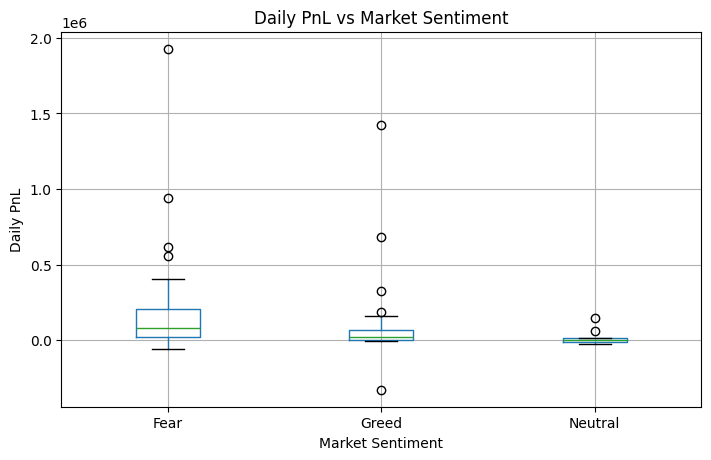

In [30]:
import matplotlib.pyplot as plt

# Boxplot of PnL vs sentiment
final.boxplot(column='daily_pnl', by='sentiment_group', figsize=(8,5))
plt.title("Daily PnL vs Market Sentiment")
plt.suptitle("")
plt.xlabel("Market Sentiment")
plt.ylabel("Daily PnL")
plt.show()



Insight 1

Trader profitability is higher during Fear periods compared to Greed and Neutral days, indicating that volatile markets create stronger profit opportunities.

Insight 2

Traders increase both trade frequency and position size during emotionally charged markets (Fear and Greed), reflecting higher risk-taking behavior.

Insight 3

High-activity traders significantly outperform low-activity traders during Fear periods, while performance differences narrow during Greed markets.